In [1]:
import pandas as pd

In [3]:
d=pd.read_csv("StudentsPerformance.csv")
d

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [4]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
dn=d.select_dtypes("int64")
dn

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75
...,...,...,...
995,88,99,95
996,62,55,55
997,59,71,65
998,68,78,77


In [6]:
d.columns[d.isna().any()]

Index([], dtype='object')

In [7]:
dn.corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


In [8]:
x=dn[["reading score","writing score"]]
y=dn["math score"]

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
model= LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_pred=model.predict(x_test)
y_pred

array([80.18552589, 65.6849504 , 69.44210877, 72.01611012, 76.82827724,
       72.22379745, 65.26957575, 59.81777453, 69.44210877, 50.08186415,
       48.22703597, 28.80271723, 75.91688168, 61.84825297, 77.57948748,
       75.03752319, 49.20250566, 46.29266872, 55.91700296, 62.39177588,
       68.05126443, 51.88808314, 68.89858586, 50.04982709, 74.7977988 ,
       71.95203599, 70.56119165, 55.67727857, 46.62850431, 57.54757169,
       58.45896725, 61.72010471, 59.33832574, 68.29098882, 71.47258721,
       53.31096455, 72.59167009, 73.10315594, 72.86343155, 20.36154   ,
       71.95203599, 62.6955744 , 61.44834326, 62.32770175, 78.31523277,
       64.50179339, 66.90014448, 32.70348879, 80.79312293, 76.52447872,
       70.04970581, 71.7123116 , 74.52603734, 55.85292884, 69.71387022,
       70.56119165, 75.30928464, 53.07124016, 76.62058991, 84.66185743,
       43.1431074 , 79.84969031, 73.64667885, 60.90482035, 83.54277455,
       72.46352184, 67.47570445, 52.49568018, 63.95827048, 86.72

In [14]:
y_test

521    91
737    53
740    80
660    74
411    84
       ..
408    52
332    62
208    74
613    65
78     61
Name: math score, Length: 200, dtype: int64

In [15]:
from sklearn.metrics import r2_score

In [16]:
r2_score(y_test,y_pred)

0.6825697127424625

In [18]:
import matplotlib.pyplot as plt

In [20]:
from mpl_toolkits.mplot3d import Axes3D

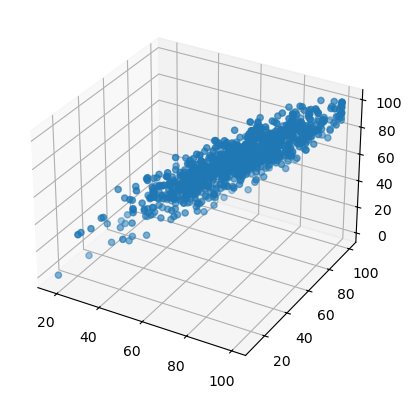

In [24]:
fig = plt.figure()
a = fig.add_subplot(111,projection="3d")
a.scatter(x["reading score"],x["writing score"],y)
#plt.xlabel(["unit_cost",""])
#plt.ylabel("math score")
plt.show()
